### Importando dados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dolar = pd.read_csv("USD_BRL Dados Históricos.csv")
ouro = pd.read_csv("Dados Históricos - Ouro Futuros.csv")
vix = pd.read_csv("Dados Históricos - S&P 500 VIX.csv")
sep = pd.read_csv("Dados Históricos - S&P 500.csv")
ibov = pd.read_csv("Dados Históricos - Ibovespa.csv")
ipca = pd.read_excel("ipca_202508SerieHist.xlsx")

In [3]:
print(ibov.shape,sep.shape,vix.shape,ouro.shape,dolar.shape)

(2479, 7) (2516, 7) (2547, 7) (2564, 7) (2609, 7)


### Convertendo coluna data para datetime e passando IPCA para dias, de acordo com os dias úteis do ibovespa

In [8]:
ibov['Data'] = pd.to_datetime(ibov['Data'],format='%d.%m.%Y')
dolar['Data'] = pd.to_datetime(dolar['Data'],format='%d.%m.%Y')
ouro['Data'] = pd.to_datetime(ouro['Data'],format='%d.%m.%Y')
vix['Data'] = pd.to_datetime(vix['Data'],format='%d.%m.%Y')
sep['Data'] = pd.to_datetime(sep['Data'],format='%d.%m.%Y')
ipca['Data'] = pd.to_datetime(ipca['Data'])

ibov['AnoMes'] = ibov['Data'].dt.to_period('M')
ipca['AnoMes'] = ipca['Data'].dt.to_period('M')

ipca_diario = []

for _, row in ipca.iterrows():
    ano_mes = row['AnoMes']
    valor_mensal = row['Variação']

    dias_uteis_mes = ibov[ibov['AnoMes'] == ano_mes]['Data']
    
    if not dias_uteis_mes.empty:
        valor_diario = valor_mensal / len(dias_uteis_mes)
        for dia in dias_uteis_mes:
            ipca_diario.append({'Data': dia, 'IPCA': valor_diario})

ipca_diario_df = pd.DataFrame(ipca_diario)



### Renomeando colunas

In [11]:
dolar.columns = ['Data', 'Último Dolar', 'Abertura', 'Máxima', 'Mínima', 'Vol.', 'Var% Dolar']
ouro.columns = ['Data', 'Último Ouro', 'Abertura', 'Máxima', 'Mínima', 'Vol.', 'Var% Ouro']
vix.columns = ['Data', 'Último Vix', 'Abertura', 'Máxima', 'Mínima', 'Vol.', 'Var% Vix']
sep.columns = ['Data', 'Último S&P 500', 'Abertura', 'Máxima', 'Mínima', 'Vol.', 'Var% S&P 500']
ibov.columns = ['Data', 'Último Ibovespa', 'Abertura', 'Máxima', 'Mínima', 'Vol.', 'Var% Ibovespa', "AnoMes"]
ipca_diario_df

,Data,IPCA
0,2015-01-30,0.059048
1,2015-01-29,0.059048
2,2015-01-28,0.059048
3,2015-01-27,0.059048
4,2015-01-26,0.059048
...,...,...
2474,2024-12-06,0.027368
2475,2024-12-05,0.027368
2476,2024-12-04,0.027368
2477,2024-12-03,0.027368


In [13]:
df_completo = pd.merge(dolar[['Data', 'Var% Dolar']], ouro[['Data', 'Var% Ouro']], 
                       on="Data", how="inner")
df_completo = pd.merge(df_completo, vix[['Data', 'Var% Vix']], on="Data", how="inner")
df_completo = pd.merge(df_completo, sep[['Data', 'Var% S&P 500']], on="Data", how="inner")
df_completo = pd.merge(df_completo, ibov[['Data', 'Var% Ibovespa']], on="Data", how="inner")
df_completo = pd.merge(df_completo, ipca_diario_df[['Data', 'IPCA']], on="Data", how="inner")

In [15]:
# Tirando sinal de %

for i in df_completo.columns[1:6]:
    df_completo[i] = pd.to_numeric(df_completo[i].str.replace('%', '', regex=False).str.replace(',', '.', regex=False),errors='coerce')


In [16]:
df = df_completo.copy()

In [19]:
df_completo["Ano"] = pd.to_datetime(df_completo['Data']).dt.year
df_completo = df_completo[df_completo["Ano"] < 2020]

### Estabelecendo correlação

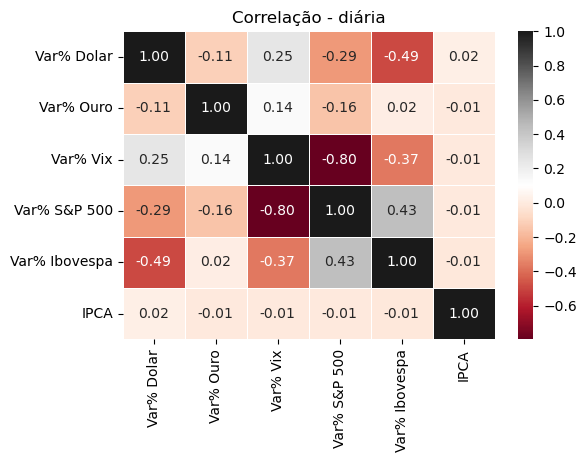

In [22]:
correlacao = df_completo[df_completo.columns[1:7]].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(correlacao, annot=True, cmap='RdGy', fmt='.2f', linewidths=0.5)
plt.title('Correlação - diária')
plt.show()


Ao analisar a correlação diária entre o S&P 500 e o VIX (conhecido como índice do medo), é uma relação inversa: quando o VIX sobe, indicando maior incerteza no mercado financeiro, o S&P 500 tende a cair, refletindo uma menor disposição dos investidores em assumir riscos.

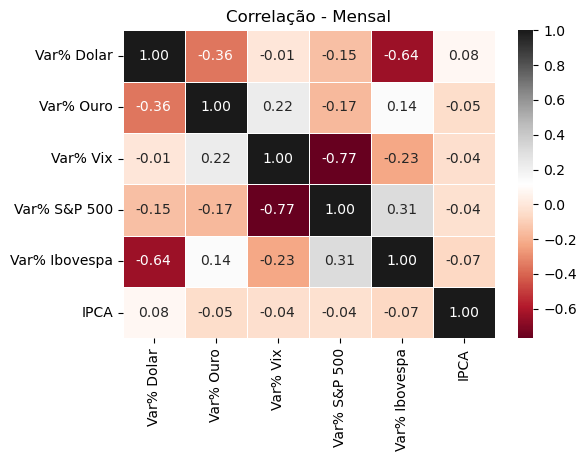

In [25]:

df_completo.loc[:,"AnoMes"] = pd.to_datetime(df_completo['Data']).dt.to_period("M").astype(str)

df_completo_mensal = df_completo.groupby("AnoMes")[df_completo.select_dtypes(include='number').columns].sum()

correlacao = df_completo_mensal.iloc[:,:6].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(correlacao, annot=True, cmap='RdGy', fmt='.2f', linewidths=0.5)
plt.title('Correlação - Mensal')
plt.show()


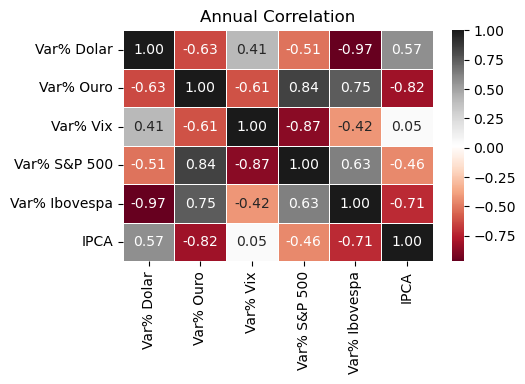

In [31]:

df_completo_mensal = df_completo.groupby("Ano")[df_completo.select_dtypes(include="number").columns].sum()

correlacao = df_completo_mensal.iloc[:, :6].corr()

plt.figure(figsize=(5, 3))
sns.heatmap(correlacao, annot=True, cmap="RdGy", fmt=".2f", linewidths=0.5)
plt.title("Annual Correlation")
plt.show()

### Adicionando Volatilidade por período (Diário, Mensal, Anual).

Considerando que o S&P 500 é o índice das maiores empresas dos Estados Unidos, é cotado em dólares, portanto a variação da sua cotação está ligada diretamente ao dólar, é importante considerar o seu retorno e volatilidade, para um investidor brasileiro.

In [35]:
df_dados = df_completo.copy()


In [37]:

import numpy as np

df_dados.rename(columns={
    'Var% Dolar': 'Dolar',
    'Var% Ouro': 'Ouro',
    'Var% Vix': 'VIX',
    'Var% S&P 500': 'S&P 500',
    'Var% Ibovespa': 'Ibovespa'
}, inplace=True)

indices = ['Dolar', 'Ouro', 'VIX', 'S&P 500', 'Ibovespa']

df_dados['Data'] = pd.to_datetime(df_dados['Data'], format='%d.%m.%Y')
df_dados['Ano'] = df_dados['Data'].dt.year
df_dados['Mes'] = df_dados['Data'].dt.month
df_dados['S&P 500'] = ((1 + df_dados['S&P 500']/100) * (1 + df_dados['Dolar']/100) - 1) * 100


def retorno_acumulado(x):
    return (np.prod(1 + x/100) - 1) * 100


def volatilidade(x):
    return np.std(x) 


retorno_mensal = df_dados.groupby(['Ano','Mes'])[indices].apply(lambda x: retorno_acumulado(x)).reset_index()

vol_mensal = df_dados.groupby(['Ano','Mes'])[indices].std().reset_index()
retorno_anual = df_dados.groupby('Ano')[indices].apply(lambda x: retorno_acumulado(x)).reset_index()

vol_anual = df_dados.groupby('Ano')[indices].std().reset_index()
vol_anual[indices] = vol_anual[indices] * np.sqrt(252)


C:\Users\ramon\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:86: FutureWarning: The behavior of DataFrame.prod with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
C:\Users\ramon\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:86: FutureWarning: The behavior of DataFrame.prod with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


# Parte - 1 e Parte - 2

 Gerando a tabela com o retorno e volatividade de cada ativo, e adicionando o Índice de Sharpe, métrica que avalia se o retorno de um ativo compensa o risco em comparação a um ativo de menor risco, no nosso caso, o Ouro que teve a menor volatilidade. melhor é a relação risco-retorno do ativo, ou seja, maior a compensação obtida pelo risco assumido em comparação ao ativo de menor risco

In [41]:
indices = ['Dolar', 'Ouro', 'S&P 500', 'Ibovespa']

ret_diario = df_dados[indices].mean()


ret_anual = ((1 + ret_diario/100) ** 252 - 1) * 100

ret_mensal = ((1 + ret_diario/100) ** 21 - 1) * 100

vol_diaria = df_dados[indices].std()
vol_mensal = vol_diaria * np.sqrt(21)
vol_anual  = vol_diaria * np.sqrt(252)


sharpe = (ret_anual - ret_anual['Ouro']) / vol_anual
sharpe['Ouro'] = np.nan  


tabela_final = pd.DataFrame({
    'Índice': indices,
    'Retorno Diário (%)': ret_diario.values,  
    'Retorno Mensal (%)': ret_mensal.values,
    'Retorno Anual (%)': ret_anual.values,
    'Volatilidade Diária (%)': vol_diaria.values,
    'Volatilidade Mensal (%)': vol_mensal.values,
    'Volatilidade Anual (%)': vol_anual.values,
    'Índice de Sharpe': sharpe.values
}).round(2)

tabela_final = tabela_final.sort_values(by="Índice de Sharpe", ascending=False)

print("        Rank de ativos - ranqueados a partir de Risco X Retorno \n")
print(tabela_final)


        Rank de ativos - ranqueados a partir de Risco X Retorno 

     Índice  Retorno Diário (%)  Retorno Mensal (%)  Retorno Anual (%)  \
3  Ibovespa                0.08                1.79              23.73   
2   S&P 500                0.07                1.41              18.32   
0     Dolar                0.03                0.60               7.46   
1      Ouro                0.02                0.40               4.86   

   Volatilidade Diária (%)  Volatilidade Mensal (%)  Volatilidade Anual (%)  \
3                     1.39                     6.39                   22.14   
2                     1.16                     5.30                   18.35   
0                     1.06                     4.87                   16.87   
1                     0.79                     3.60                   12.48   

   Índice de Sharpe  
3              0.85  
2              0.73  
0              0.15  
1               NaN  


In [42]:
tabela_final.to_excel("TabelaDeAtivos.xlsx")

### Parte 3 – Estratégia de Investimento - Evolução mensal

Apartir da planilha do excel "TabelaDeAtivos.xlsx" na aba "calculo carteira", foi decido que a composição da carteira seria:
Ouro Spot: 25%
USDBRL: 20%
IBOVESPA: 25%
S%P 500: 30

In [47]:
df.columns = ["Data", "Dolar", "Ouro", "VIX", "S&P 500", "Ibovespa", "IPCA"]
df1 = df.copy()
df = df[df["Data"] > "01/01/2020"]
df1["Ano"] = df["Data"].dt.year
df["Ano"] = df["Data"].dt.year
df["Mes"] = df["Data"].dt.month

In [48]:
df_mensal = (
    df.groupby(["Ano", "Mes"])[["Dolar", "Ouro", "VIX", "S&P 500", "Ibovespa", "IPCA"]].agg(retorno_acumulado).reset_index())


In [51]:
df_mensal["Saldo Ibovespa"] = ""
df_mensal["Saldo Ouro"] = ""
df_mensal["Saldo Dolar"] = ""
df_mensal["Saldo S&P 500"] = ""
for i, row in df_mensal.iterrows():
    if i == 0:
        df_mensal.at[i, "Saldo Ibovespa"] = 25000 * (1 + row["Ibovespa"]/100)
        df_mensal.at[i, "Saldo Ouro"]     = 25000     * (1 + row["Ouro"]/100)
        df_mensal.at[i, "Saldo Dolar"]    = 20000    * (1 + row["Dolar"]/100)
        df_mensal.at[i, "Saldo S&P 500"]  = 30000  * (1 + row["S&P 500"]/100)
    else:
        df_mensal.at[i, "Saldo Ibovespa"] = df_mensal.at[i-1, "Saldo Ibovespa"] * (1 + row["Ibovespa"]/100)
        df_mensal.at[i, "Saldo Ouro"]     = df_mensal.at[i-1, "Saldo Ouro"]     * (1 + row["Ouro"]/100)
        df_mensal.at[i, "Saldo Dolar"]    = df_mensal.at[i-1, "Saldo Dolar"]    * (1 + row["Dolar"]/100)
        df_mensal.at[i, "Saldo S&P 500"]  = df_mensal.at[i-1, "Saldo S&P 500"]  * (1 + row["S&P 500"]/100)

In [53]:
df_mensal["Saldo Total"] =  df_mensal[["Saldo Dolar", "Saldo Ouro", "Saldo S&P 500", "Saldo Ibovespa"]].sum(axis=1)

In [ ]:
df_mensal["Rentabilidade Total"] = df_mensal["Saldo Total"].pct_change() * 100

In [65]:
df_mensal.columns  = ['Ano', 'Mes', 'Dolar', 'Ouro', 'VIX', 'S&P 500', 'Ibovespa', 'IPCA',
       'Ibovespa Balance', 'Gold Balance', 'Dollar Balance', 'S&P 500 Balance',
       'Total Balance', 'Total Return', 'Período']


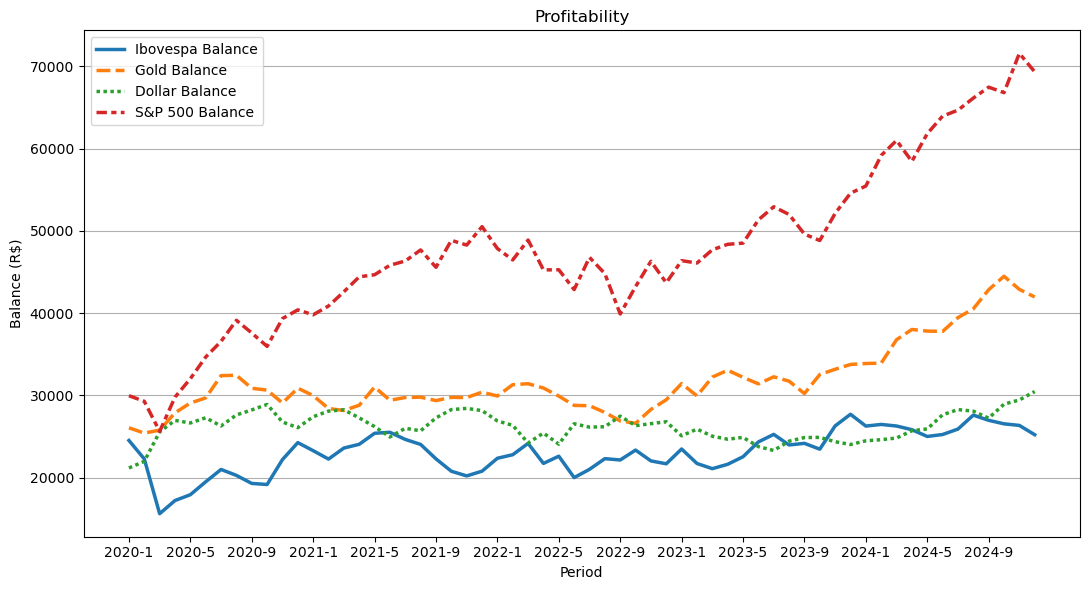

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df_mensal["Período"] = df_mensal["Ano"].astype(str) +"-"+ df_mensal["Mes"].astype(str)
colunas = ['Ibovespa Balance', 'Gold Balance', 'Dollar Balance', 'S&P 500 Balance']


plt.figure(figsize=(11,6))
sns.lineplot(data=df_mensal[colunas + ["Período"]].set_index(["Período"]), linewidth=2.5 )

plt.title("Profitability")
plt.xlabel("Period")
plt.ylabel("Balance (R$)")
plt.xticks(df_mensal["Período"][::4]) 
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()


### Gerando tabelas de retorno anual completo

In [136]:
df_anual = (
    df1.groupby(["Ano"])[["Dolar", "Ouro", "VIX", "S&P 500", "Ibovespa", "IPCA"]].agg(retorno_acumulado).reset_index())

In [138]:
pesos = {
    "Dolar": 0.20,
    "Ouro": 0.25,
    "S&P 500": 0.30,
    "Ibovespa": 0.25
}

valor_carteira = 1.0
retornos_anuais = []
volatilidades = []

for i, row in df_anual.iterrows():
    ano = row["Ano"]
    df2 = df1[df1["Ano"] == ano]

    # Retorno da estratégia
    retorno_ano = sum([
        pesos["Dolar"] * (1 + row["Dolar"] / 100),
        pesos["Ouro"] * (1 + row["Ouro"] / 100),
        pesos["S&P 500"] * (1 + row["S&P 500"] / 100),
        pesos["Ibovespa"] * (1 + row["Ibovespa"] / 100)
    ])
    valor_carteira *= retorno_ano
    retorno_percentual = (retorno_ano - 1) * 100
    retornos_anuais.append(retorno_percentual)

    # Volatilidade anualizada com os pesos atuais
    vol_dolar = df2["Dolar"].std() * np.sqrt(252)
    vol_ouro = df2["Ouro"].std() * np.sqrt(252)
    vol_sp500 = df2["S&P 500"].std() * np.sqrt(252)
    vol_ibov = df2["Ibovespa"].std() * np.sqrt(252)

    vol_total = np.sqrt(
        (pesos["Dolar"]**2 * vol_dolar**2) +
        (pesos["Ouro"]**2 * vol_ouro**2) +
        (pesos["S&P 500"]**2 * vol_sp500**2) +
        (pesos["Ibovespa"]**2 * vol_ibov**2)
    )
    volatilidades.append(vol_total)
    novos_valores = {
        ativo: pesos[ativo] * (1 + row[ativo] / 100)
        for ativo in pesos
    }
    soma_valores = sum(novos_valores.values())
    pesos = {ativo: novos_valores[ativo] / soma_valores for ativo in pesos}

# Atualiza o df_anual
df_anual["Retorno Estratégia"] = retornos_anuais
df_anual["Volatilidade"] = volatilidades

In [140]:

df_anual["Retorno Estratégia Real"] = ((1 + (df_anual["Retorno Estratégia"] / 100) / (1+ (df_anual["IPCA"] / 100))) - 1) * 100


In [142]:
df_anual[["Ano","Dolar", "Ouro", "S&P 500", "Ibovespa", "Retorno Estratégia","Retorno Estratégia Real","Volatilidade","VIX","IPCA"]].\
to_excel("dadoscompleto.xlsx", index=False)

In [144]:
df_anual

,Ano,Dolar,Ouro,VIX,S&P 500,Ibovespa,IPCA,Retorno Estratégia,Volatilidade,Retorno Estratégia Real
0,2020.0,30.337324,23.488343,-32.857703,34.633239,-2.995097,4.471440,21.580748,16.590402,20.657079
1,2021.0,7.961759,-1.563097,-25.017169,25.053766,-14.313829,9.885412,6.778045,8.046752,6.168285
2,2022.0,-4.802852,-3.065816,-19.242737,-13.514700,4.322163,5.677623,-6.325120,11.338789,-5.985298
3,2023.0,-10.335191,14.573808,-53.210456,24.940956,27.774985,4.541960,15.163412,6.985642,14.504618
4,2024.0,26.798374,24.319366,-3.250447,27.023808,-8.981969,4.682587,19.212169,6.958771,18.352784


### Gerando tabelas de retorno anual resumo

Período completo

In [148]:

def resumo_ativo(coluna):
    retorno_medio = df_anual[coluna].mean()
    volatilidade = df_anual[coluna].std()
    return pd.Series({'Retorno Anual (%)': retorno_medio, 'Volatilidade Anual (%)': volatilidade})


ativos = ['Dolar', 'Ouro', 'VIX', 'S&P 500', 'Ibovespa', 'Retorno Estratégia',"Retorno Estratégia Real", "IPCA"]
resumo = pd.DataFrame({ativo: resumo_ativo(ativo) for ativo in ativos}).T
resumo.index.name = 'Ativo'

print("Período Completo")
resumo

Período Completo


,Retorno Anual (%),Volatilidade Anual (%)
Ativo,,
Dolar,9.991883,18.252333
Ouro,11.550521,13.231587
VIX,-26.715702,18.364671
S&P 500,19.627414,18.947032
Ibovespa,1.161250,16.415850
Retorno Estratégia,11.281851,11.339240
Retorno Estratégia Real,10.739494,10.852551
IPCA,5.851804,2.306973


In [150]:

def resumo_ativo2(coluna):
    df = df_anual[df_anual["Ano"] > 2020]
    retorno_medio = df[coluna].mean()
    volatilidade = df[coluna].std()
    return pd.Series({'Retorno Anual (%)': retorno_medio, 'Volatilidade Anual (%)': volatilidade})


ativos = ['Dolar', 'Ouro', 'VIX', 'S&P 500', 'Ibovespa', 'Retorno Estratégia',"Retorno Estratégia Real", "IPCA"]
resumo1 = pd.DataFrame({ativo: resumo_ativo2(ativo) for ativo in ativos}).T
resumo1.index.name = 'Ativo'

print("Período 2020-2024")
resumo1

Período 2020-2024


,Retorno Anual (%),Volatilidade Anual (%)
Ativo,,
Dolar,4.905523,16.484027
Ouro,8.566066,13.192928
VIX,-25.180202,20.831781
S&P 500,15.875958,19.617099
Ibovespa,2.200337,18.764563
Retorno Estratégia,8.707127,11.280209
Retorno Estratégia Real,8.260097,10.772857
IPCA,6.196895,2.510427


In [152]:
with pd.ExcelWriter("DadosAnuais.xlsx", engine="xlsxwriter") as writer:
    resumo.to_excel(writer, sheet_name="Completo", index=False)
    resumo1.to_excel(writer, sheet_name="2020-2024", index=False)
